In [1]:
import numpy as np
N = 1024
d = 64

BIG_NUMBER = 10

Q = BIG_NUMBER * np.random.randn(N,d)
K = BIG_NUMBER * np.random.randn(N,d)
V = np.random.randn(N,d)

# (Offline) attention with safe softmax
This is the offline attention calculation with safe softmax.
You do not need to modify the following code block.

In [2]:
S = Q@K.T
S = S - np.max(S, axis = 1,keepdims=True) # to prevent overflow
P = np.exp(S)/ np.sum(np.exp(S),axis = 1, keepdims=True)
O_offline = P @ V

# Flash attention with safe softmax

Your task is to implement flash attention with safe softmax.

For simplicity, we will not implement causal masking, as we've done in lecture.

Consider the following matrix partitioned into 4x4 =16 equal-sized blocks:

$$
\mathbf{S} = 
\mathbf{Q}\mathbf{K}^\top = 
\begin{bmatrix}
\mathbf{Q}_1 \\ \mathbf{Q}_2 \\ \mathbf{Q}_3 \\ \mathbf{Q}_4
\end{bmatrix}
\begin{bmatrix}
\mathbf{K}_1^\top & \mathbf{K}_2^\top & \mathbf{K}_3^\top & \mathbf{K}_4^\top
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{S}_{11} & \mathbf{S}_{12} & \mathbf{S}_{13} & \mathbf{S}_{14} \\
\mathbf{S}_{21} & \mathbf{S}_{22} & \mathbf{S}_{23} & \mathbf{S}_{24} \\
\mathbf{S}_{31} & \mathbf{S}_{32} & \mathbf{S}_{33} & \mathbf{S}_{34} \\
\mathbf{S}_{41} & \mathbf{S}_{42} & \mathbf{S}_{43} & \mathbf{S}_{44} \\
\end{bmatrix}
$$
where $\mathbf{S}_{ij} = \mathbf{Q}_i \mathbf{K}_j^\top$.

Some of the $\mathbf{S}_{ij}$ will contain large values, which makes the flash attention code `lec11-ex4-flash-attention.ipynb` from Lecture 11 suffer numerical overflow.

Implement numerically stable (i.e., safe) flash attention by integrating the "subtracting the max" strategy from `lec11-ex2-online-softmax-safe.ipynb` with the code from `lec11-ex4-flash-attention.ipynb`, by filling in the code block below.

Hints:
1. You should use the variable `rmaxs_temp` to record the row-wise maximums in $\mathbf{S}_{i1}, \mathbf{S}_{i2},\dots, \mathbf{S}_{ij}$ up to and including block `j` in the inner loop.
2. Use `rmaxs` to record the row-wise maximums $\mathbf{S}_{i1}, \mathbf{S}_{i2},\dots, \mathbf{S}_{i(j-1)}$ up to and *excluding* block `j`.
3. The `assert` at the bottom of the codeblock should pass (in which case the output will be silent).

Requirements:
1. During the `i`-th iteration of the outer loop, only `Q[ I[i], : ]` can be read from. No accessing other parts of `Q` allowed.
2. During the `j`-th iteration of the inner loop, only `K[ I[j], : ]` can be read from. No accessing other parts of `K` allowed.
3. During the `j`-th iteration of the inner loop, only `V[ I[j], : ]` can be read from. No accessing other parts of `V` allowed.
4. During the `i`-th iteration of the outer loop, only `O[ I[i], : ]` can be written to. No accessing other parts of `O` allowed.
5. Do not modify `O` outside the outer/inner loops below.
6. You may only edit/add/delete code inside the inner loop. Do not edit code anywhere else.
7. You may allocate at most 5 additional "helper" numpy arrays of shape `(N/B, 1)`. My implemention requires only 2 additional such arrays.
8. Trying to circumvent the requirement of this problem will result in no credit.

In [3]:
# block indices
B = 4  # number of blocks
block_size = N // B

# indices for the blocks
I = [np.arange(j * block_size, (j + 1) * block_size) for j in range(B)]

# output matrix, initialized to be all zeros
O = np.zeros_like(V)

# row-wise sums to keep track of exp(Si1) + exp(Si2) + ... + exp(Sij)
# one horizontal block of S at a time
rsums = np.zeros((N, 1))

# row-wise maximums to keep track of the running max across blocks
# one horizontal block of S at a time
# initialized as negative infinity
rmaxs = np.full((N, 1), -np.inf)

for i in range(B):  # The outer loop (do NOT modify this line)
    # Begin of outer loop
    Qi = Q[I[i], :]  # (do NOT modify this line)
    for j in range(B):  # The inner loop
        # Begin of inner loop
        # You may only edit/add/delete code inside the inner loop

        Kj = K[I[j], :]
        Vj = V[I[j], :]
        Sij = Qi @ Kj.T  # shape: (block_size, block_size)

        # compute the per row max for the current block
        m_ij = np.max(Sij, axis=1, keepdims=True)  # shape: (block_size, 1)

        # previous running max and sums for rows in block i
        m_prev = rmaxs[I[i], :]                    # shape: (block_size, 1)
        s_prev = rsums[I[i], :]                    # shape: (block_size, 1)

        # new running max
        m_new = np.maximum(m_prev, m_ij)           # shape: (block_size, 1)

        # scale factor to keep numerical stability
        # this rescales previous contributions from the old max to the new max
        prev_scale = np.exp(m_prev - m_new)        # shape: (block_size, 1)

        # shift Sij by the new running max and exponentiate
        exp_Sij = np.exp(Sij - m_new)              # shape: (block_size, block_size)

        # update running denominator sums
        s_new = s_prev * prev_scale + np.sum(exp_Sij, axis=1, keepdims=True)  # (block_size, 1)

        # update the numerator O, scaling previous contributions and adding current block
        O[I[i], :] = O[I[i], :] * prev_scale + exp_Sij @ Vj  # (block_size, d)

        # write back new running max and sums
        rmaxs[I[i], :] = m_new
        rsums[I[i], :] = s_new

        # You may only edit/add/delete code inside the inner loop
        # End of inner loop

    O[I[i], :] = O[I[i], :] / rsums[I[i], :]  # (do NOT modify this line)
    # End of outer loop

assert np.allclose(O_offline, O)


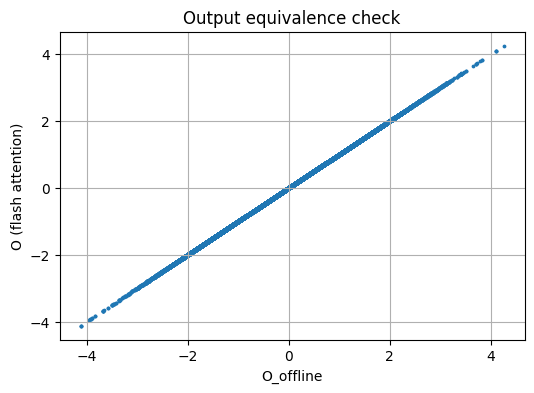

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(O_offline.flatten(), O.flatten(), s=3)
plt.xlabel("O_offline")
plt.ylabel("O (flash attention)")
plt.title("Output equivalence check")
plt.grid(True)
plt.show()
